<a href="https://colab.research.google.com/github/NVHau-K14/Tuan03_ThucHanh_DeepLearning-/blob/main/ANN_NhanDienQuanAo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikeras

3.1. Nạp thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

3.2. Đọc tâp dữ liệu FASHION MNIST

In [ ]:
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

3.3. Xủ lý dữ liệu

In [ ]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('classes:', np.unique(y_train))


3.4. Trực quan hóa dữ liệu

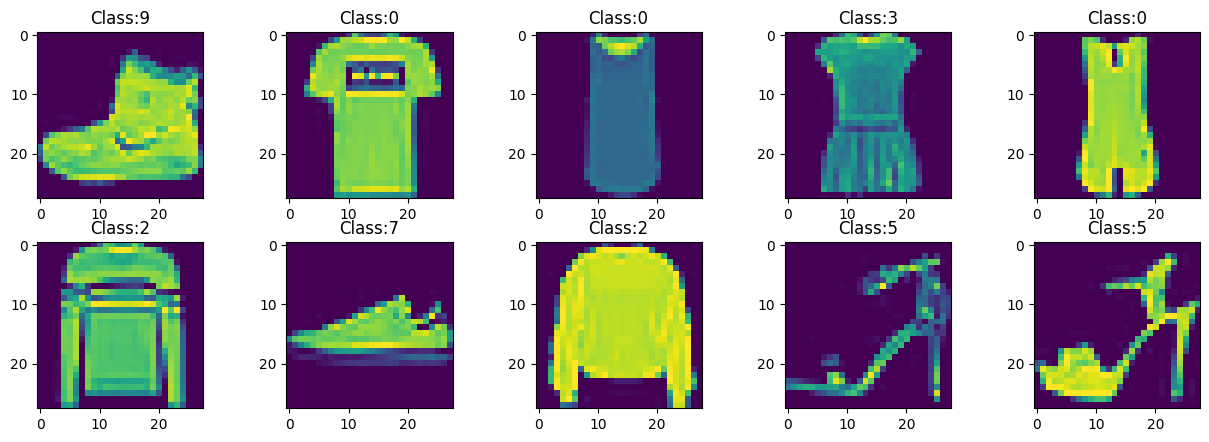

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(wspace=0.5)
plt.show()

3.5. Xây dựng mô hình học ANN

In [6]:
fashion_model = Sequential()

fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='normal', activation='relu'))

fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

3.6. Huấn luyện ANN model

In [ ]:
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

3.7. Đánh giá ANN model

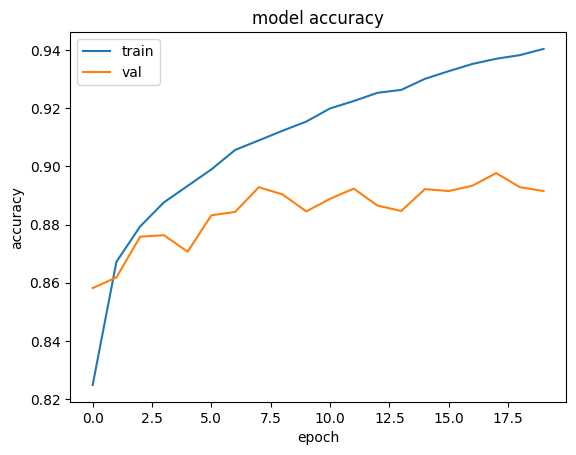

In [8]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

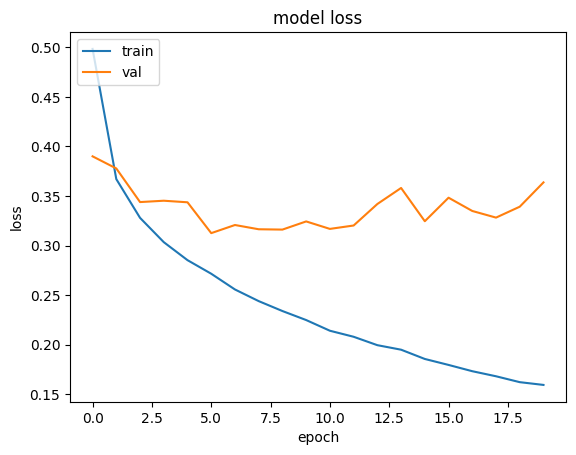

In [9]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

3.8. Dự báo ảnh mới

In [10]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
4 4


3.9. Đọc tập dữ liệu từ file

In [ ]:
#Đọc tập dữ liệu từ file
mnist_train_path = '/content/sample_data/fashion-mnist_train.csv'
mnist_test_path = '/content/sample_data/fashion-mnist_test.csv'

mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)

print(mnist_train.head())
print(mnist_train.shape)

In [19]:
X_train = mnist_train.iloc[:, 1:]
X_test = mnist_test.iloc[:, 1:]
print(X_train.shape)

y_train = mnist_train.iloc[:, 0]
y_test = mnist_test.iloc[:, 0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

(3311, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [21]:
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)

In [23]:
print(np.argmax(model.predict(X_test)[0]), y_test[0])

104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
0 0


In [26]:
img_size = (28, 28)
img = tf.keras.preprocessing.image.load_img('/content/sample_data/dress.jpg', color_mode='grayscale', target_size=img_size)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array,(784))
img_array = tf.expand_dims(img, 0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)

img_predict = model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
[[nan nan nan nan nan nan nan nan nan nan]]
0
